In [1]:
import pandas as pd
df = pd.read_csv("healthcare_patient_journey.csv")
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   patient_id           3000 non-null   int64 
 1   age                  3000 non-null   int64 
 2   gender               3000 non-null   object
 3   chronic_condition    3000 non-null   int64 
 4   admission_type       3000 non-null   object
 5   department           3000 non-null   object
 6   wait_time_min        3000 non-null   int64 
 7   length_of_stay_days  3000 non-null   int64 
 8   procedures_count     3000 non-null   int64 
 9   medication_count     3000 non-null   int64 
 10  complications        3000 non-null   int64 
 11  discharge_status     3000 non-null   object
 12  readmitted_30d       3000 non-null   int64 
 13  total_cost_€         3000 non-null   int64 
 14  satisfaction_score   3000 non-null   int64 
dtypes: int64(11), object(4)
memory usage: 351.7+ KB


,patient_id,age,chronic_condition,wait_time_min,length_of_stay_days,procedures_count,medication_count,complications,readmitted_30d,total_cost_€,satisfaction_score
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,53.051333,0.405667,33.326333,3.535000,2.435667,3.404667,0.160333,0.234667,2772.040000,2.803000
std,866.169729,20.704901,0.491102,17.111559,2.024881,1.595842,1.890883,0.366976,0.423861,1086.215721,0.838506
min,1.000000,18.000000,0.000000,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,750.000000,1.000000
25%,750.750000,35.000000,0.000000,20.750000,2.000000,1.000000,2.000000,0.000000,0.000000,1900.000000,2.000000
50%,1500.500000,53.000000,0.000000,33.000000,3.000000,2.000000,3.000000,0.000000,0.000000,2670.000000,3.000000
75%,2250.250000,71.000000,1.000000,45.000000,5.000000,3.000000,5.000000,0.000000,0.000000,3490.000000,3.000000
max,3000.000000,89.000000,1.000000,103.000000,11.000000,10.000000,11.000000,1.000000,1.000000,6610.000000,5.000000


In [ ]:
print("--------Avg cost by department---------")
avg_cost_dept = df.groupby('department')['total_cost_€'].mean()
print(avg_cost_dept)
print("/n----Avg Wait time by admission type----")
avg_wait_admission = df.groupby('admission_type')['wait_time_min'].mean()
print(avg_wait_admission)
print("/n----Readmission Rate----")
readmission_rate = df['readmitted_30d'].mean()*100
print(readmission_rate)

--------Avg cost by department---------
department
Cardiology    2806.122449
ER            2725.498339
Neurology     2757.813022
Oncology      2772.056856
Polyclinic    2798.939641
Name: total_cost_€, dtype: float64
/n----Avg Wait time by admission type----
admission_type
emergency    25.484018
scheduled    44.335737
Name: wait_time_min, dtype: float64
/n----Readmission Rate----
23.466666666666665


/tmp/ipykernel_5083/2334358523.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='satisfaction_score', palette="Purples_r",ax=ax1)
/tmp/ipykernel_5083/2334358523.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_cost_sorted, x='department',y='total_cost_€', palette="Oranges_r", ax=ax2)


Text(0, 0.5, 'Avg Cost €')

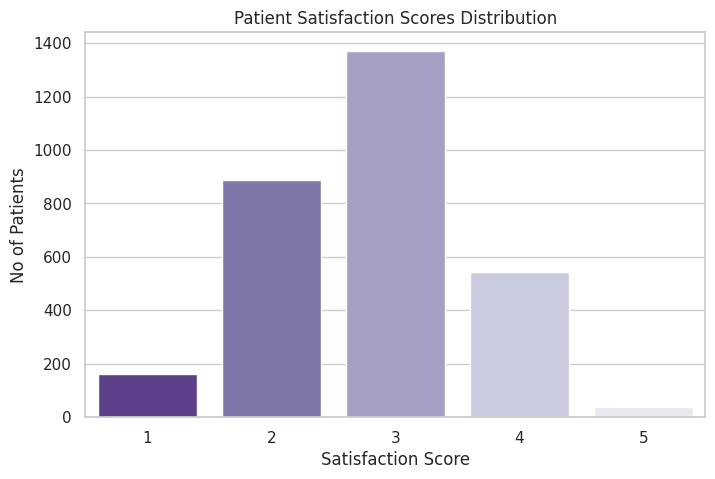

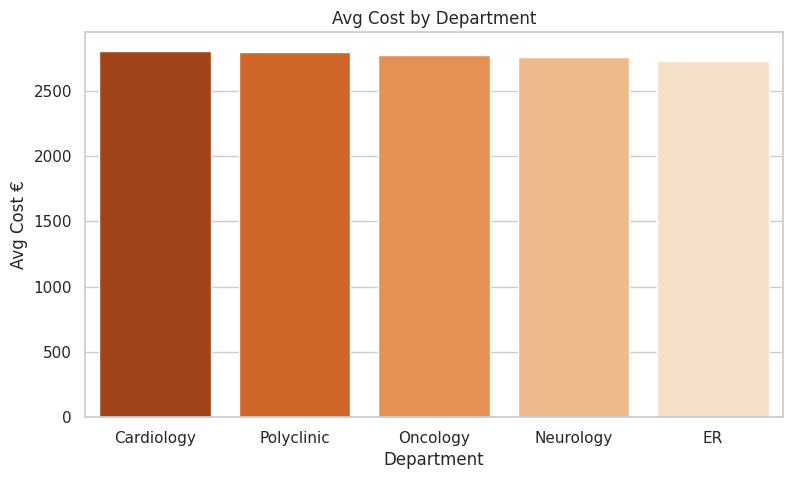

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

fig1,ax1 = plt.subplots(figsize=(8,5))
sns.countplot(data=df, x='satisfaction_score', palette="Purples_r",ax=ax1)
ax1.set_title('Patient Satisfaction Scores Distribution')
ax1.set_xlabel('Satisfaction Score')
ax1.set_ylabel('No of Patients')

df_cost_sorted = df.groupby('department')['total_cost_€'].mean().reset_index()
df_cost_sorted = df_cost_sorted.sort_values(by = 'total_cost_€', ascending=False)

fig2,ax2 = plt.subplots(figsize=(9,5))
sns.barplot(data=df_cost_sorted, x='department',y='total_cost_€', palette="Oranges_r", ax=ax2)
ax2.set_title('Avg Cost by Department')
ax2.set_xlabel('Department')
ax2.set_ylabel('Avg Cost €')



In [2]:
high_risk_patients = df[(df['age']>60) & (df['chronic_condition']==1)]

print(f"-----High Risk Patient------")
print(f"Total High-risk patients : {len(high_risk_patients)}")
print(f"Avg hospital stay : {high_risk_patients['length_of_stay_days'].mean():.1f}")

critical_cases = df[(df['complications'] == 1) & (df['readmitted_30d'] == 1)]
print(f"-----Critical Cases(Complications+Readmitted)------")
print(f"Total Critical cases : {len(critical_cases)}")
print(f"Avg Critical cost : €{critical_cases['total_cost_€'].mean():.2f}")

-----High Risk Patient------
Total High-risk patients : 515
Avg hospital stay : 4.7
-----Critical Cases(Complications+Readmitted)------
Total Critical cases : 256
Avg Critical cost : €3145.94


In [4]:
high_risk_patients.to_csv('high_risk_patients.csv', index=False)
print("Report successfully created and saved")


Report successfully created and saved
